In [1]:
%load_ext autoreload
%autoreload 2
#
import warnings
warnings.filterwarnings('ignore')
#
import numpy as np
np.set_printoptions(legacy='1.25')
import pandas as pd
import os
import torch
import random
from tqdm.notebook import tqdm
import itertools
from itertools import product
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from PIL import Image, ImageDraw, ImageFont
import pytorch_lightning as pl
from torch.nn import functional as F
import pyrootutils
#
import colorsys
import string
#
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from qwen_vl_utils import process_vision_info

In [2]:
# This notebook can be run end-to-end in a few minutes. 
# Remove the guards to replicate experiments entirely.

In [3]:
first_12 = string.ascii_uppercase[:12]
all_letters = string.ascii_uppercase
font_size = 50
font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", font_size)
CANVAS_SIZE = (500, 500)
STENCIL_SIZE = 50

# UTILS

In [4]:
def hue_sim(h1, h2):
    if h1==-1 or h2==-1:
        return 0.
    dist = min(abs(h1 - h2), 360 - abs(h1 - h2))  # Accounts for hue wrapping
    return 1-(dist/180)

In [5]:
def make_image_query(col):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    draw = ImageDraw.Draw(canvas)
    hsv_color = (col, 1.0, 1.0)  # Green in HSV
    rgb_color = tuple(int(c * 255) for c in colorsys.hsv_to_rgb(hsv_color[0] / 360, hsv_color[1], hsv_color[2]))
    rect_position = (225, 225, 275, 275)  # (x1, y1, x2, y2)
    draw.rectangle(rect_position, fill=rgb_color)
    return canvas

In [6]:
def make_query(n):
    q = 'In the first picture there are '+str(n)+' squares of different colors, labelled with uppercase letters: '
    q += 'A B C D E F G H I J K L '[:(n*2)]
    q += '\nIn the second picture there is only one target square.\n'+\
    'Identify which square in the first picture is most similar to the target square in the second picture. '+\
    'Reply with the corresponding letter and nothing else.'
    return q

make_query(6)

'In the first picture there are 6 squares of different colors, labelled with uppercase letters: A B C D E F \nIn the second picture there is only one target square.\nIdentify which square in the first picture is most similar to the target square in the second picture. Reply with the corresponding letter and nothing else.'

In [7]:
def find_value_qwen(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['Ġ'+x for x in candidates] + ['ġ'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found

In [8]:
def get_qwen():
    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained('Qwen/Qwen2.5-VL-7B-Instruct', 
                                                                torch_dtype='auto', device_map='auto')
    qwen_processor = AutoProcessor.from_pretrained('Qwen/Qwen2.5-VL-7B-Instruct') 
    qwen_vocab = qwen_processor.tokenizer.get_vocab()
    return qwen_model,qwen_processor,qwen_vocab

In [9]:
def get_qwen_inputs_2imgs(model,processor,img_path1,img_path2,query_string):
    batch_messages = [[{'role': 'system', 'content': 'You are a helpful assistant.'}, 
      {'role': 'user', 'content': [{'type': 'image', 'image': 'file://'+img_path1}, 
                                   {'type': 'image', 'image': 'file://'+img_path2}, 
        {'type': 'text', 'text': query_string}]}]]    
    texts = [
            processor.apply_chat_template(
                msg,
                tokenize=False,
                add_generation_prompt=True
            ) for msg in batch_messages
        ]
    image_inputs, video_inputs = process_vision_info(batch_messages)
    inputs = processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors='pt'
        ).to(model.device)
    return inputs

In [10]:
def ask_qwen_2imgs(model,processor,vocab,img_path1,img_path2,query):
    inputs = get_qwen_inputs_2imgs(model,processor,img_path1,img_path2,query)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=128,
                return_dict_in_generate=True, output_scores=True)
    num_system_tokens = 14
    num_image_tokens = 326  # 18 x 18 + 2 (start, end image token)
    num_user_tokens = inputs.input_ids.shape[1] - num_system_tokens - num_image_tokens
    str_out = processor.decode(output.sequences[0][num_system_tokens+num_image_tokens+num_user_tokens:-1])
    scores = output['scores'][0][0]
    return {'Q':query,'A':str_out,'scores':scores}

In [11]:
def find_value_gemma(dictionary,answer):
    candidates = [answer,answer.lower(),answer.capitalize(),answer.upper()]
    candidates = candidates + ['▁'+x for x in candidates]
    candidates = candidates + [x[:-1] for x in candidates] + [x[:-2] for x in candidates] + \
                                [x[:-3] for x in candidates] + [x[:-4] for x in candidates]
    for key in candidates:
        if key in dictionary:
            return dictionary[key]  # Return value as soon as a match is found
    return "----------------------------------"+answer  # No match found

In [12]:
def get_gemma():
    model_id = "google/gemma-3-12b-it"    
    gemma_model = Gemma3ForConditionalGeneration.from_pretrained(
        model_id, device_map="auto"
    ).eval()    
    gemma_processor = AutoProcessor.from_pretrained(model_id)
    gemma_vocab = gemma_processor.tokenizer.get_vocab()
    return gemma_model,gemma_processor,gemma_vocab

In [13]:
def get_gemma_inputs_2imgs(model,processor,img_path1,img_path2,query_string):
    messages = [{"role": "system","content": [{"type": "text", "text": "You are a helpful assistant."}]},
    {"role": "user","content": [{"type": "image", "image": img_path1},{"type": "image", "image": img_path2},
                                {"type": "text", "text": query_string}]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device, dtype=torch.bfloat16)
    return inputs

In [14]:
def ask_gemma_2imgs(model,processor,vocab,im1,im2,query):
    inputs = get_gemma_inputs_2imgs(model,processor,im1,im2,query)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=100, do_sample=False,
            return_dict_in_generate=True, output_scores=True)
    str_out = processor.decode(generation['sequences'][0][input_len:-1])
    scores = generation['scores'][0][0]
    return {'Q':query,'A':str_out,'scores':scores}

# REFERENCE DATASET

In [15]:
COLOR_REFERENCE_DATASET = 'color_reference_dataset/'
os.makedirs(COLOR_REFERENCE_DATASET, exist_ok=True)

In [16]:
def make_image_4items(random_colors):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    draw = ImageDraw.Draw(canvas)
    for k in range(4):
        row = k // 4
        col = k % 4
        hsv_color = (random_colors[k], 1.0, 1.0)  # Green in HSV
        rgb_color = tuple(int(c * 255) for c in colorsys.hsv_to_rgb(hsv_color[0] / 360, hsv_color[1], hsv_color[2]))
        x = [75,175,275,375][col]
        y = [225][row]
        rect_position = (x, y, x+50, y+50)  # (x1, y1, x2, y2)
        draw.rectangle(rect_position, fill=rgb_color)
        text_bbox = font.getbbox(first_12[k])
        deltax = (STENCIL_SIZE - (text_bbox[2] - text_bbox[0]))//2
        draw.text((x+deltax,y+50), first_12[k], fill="black", font=font)
    return canvas

def make_image_6items(random_colors):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    draw = ImageDraw.Draw(canvas)
    for k in range(6):
        row = k // 3
        col = k % 3
        hsv_color = (random_colors[k], 1.0, 1.0)  # Green in HSV
        rgb_color = tuple(int(c * 255) for c in colorsys.hsv_to_rgb(hsv_color[0] / 360, hsv_color[1], hsv_color[2]))
        x = [100,225,350][col]
        y = [125,275][row]
        rect_position = (x, y, x+50, y+50)  # (x1, y1, x2, y2)
        draw.rectangle(rect_position, fill=rgb_color)
        text_bbox = font.getbbox(first_12[k])
        deltax = (STENCIL_SIZE - (text_bbox[2] - text_bbox[0]))//2
        draw.text((x+deltax,y+50), first_12[k], fill="black", font=font)
    return canvas

def make_image_8items(random_colors):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    draw = ImageDraw.Draw(canvas)
    for k in range(8):
        row = k // 4
        col = k % 4
        hsv_color = (random_colors[k], 1.0, 1.0)  # Green in HSV
        rgb_color = tuple(int(c * 255) for c in colorsys.hsv_to_rgb(hsv_color[0] / 360, hsv_color[1], hsv_color[2]))
        x = [75,175,275,375][col]
        y = [125,275][row]
        rect_position = (x, y, x+50, y+50)  # (x1, y1, x2, y2)
        draw.rectangle(rect_position, fill=rgb_color)
        text_bbox = font.getbbox(first_12[k])
        deltax = (STENCIL_SIZE - (text_bbox[2] - text_bbox[0]))//2
        draw.text((x+deltax,y+50), first_12[k], fill="black", font=font)
    return canvas

def make_image_10items(random_colors):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    draw = ImageDraw.Draw(canvas)
    for k in range(10):
        row = k // 5
        col = k % 5
        hsv_color = (random_colors[k], 1.0, 1.0)  # Green in HSV
        rgb_color = tuple(int(c * 255) for c in colorsys.hsv_to_rgb(hsv_color[0] / 360, hsv_color[1], hsv_color[2]))
        x = [25,125,225,325,425][col]
        y = [150,300][row]
        rect_position = (x, y, x+50, y+50)  # (x1, y1, x2, y2)
        draw.rectangle(rect_position, fill=rgb_color)
        text_bbox = font.getbbox(first_12[k])
        deltax = (STENCIL_SIZE - (text_bbox[2] - text_bbox[0]))//2
        draw.text((x+deltax,y+50), first_12[k], fill="black", font=font)
    return canvas

def make_image_12items(random_colors):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    draw = ImageDraw.Draw(canvas)
    for k in range(12):
        row = k // 4
        col = k % 4
        hsv_color = (random_colors[k], 1.0, 1.0)  # Green in HSV
        rgb_color = tuple(int(c * 255) for c in colorsys.hsv_to_rgb(hsv_color[0] / 360, hsv_color[1], hsv_color[2]))
        x = [75,175,275,375][col]
        y = [50,200,350][row]
        rect_position = (x, y, x+50, y+50)  # (x1, y1, x2, y2)
        draw.rectangle(rect_position, fill=rgb_color)
        text_bbox = font.getbbox(first_12[k])
        deltax = (STENCIL_SIZE - (text_bbox[2] - text_bbox[0]))//2
        draw.text((x+deltax,y+50), first_12[k], fill="black", font=font)
    return canvas

In [17]:
def make_image_multi(num_stencils,random_colors):
    if num_stencils == 4:
        return make_image_4items(random_colors)
    if num_stencils == 6:
        return make_image_6items(random_colors)
    if num_stencils == 8:
        return make_image_8items(random_colors)
    if num_stencils == 10:
        return make_image_10items(random_colors)
    if num_stencils == 12:
        return make_image_12items(random_colors)
    else:
        return None

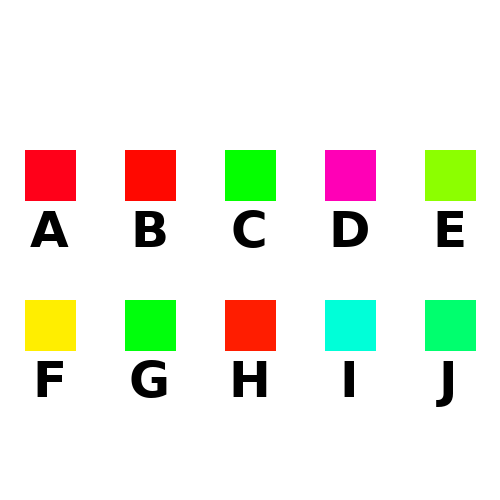

In [18]:
make_image_10items(np.random.randint(360,size=10))

In [19]:
# Create column names dynamically
hue_columns = ['HUE_'+k for k in first_12]
dtype_dict = {col: pd.Int64Dtype() for col in hue_columns}
dtype_dict['ID'] = 'str'
columns = ['ID','N_STENCILS']+hue_columns
stencil_values = [4,6,8,10,12]
num_exp = 1000
nrows = len(stencil_values)*num_exp

In [20]:
metadata = pd.DataFrame(-1, index=range(nrows), columns=columns)
for i,row in metadata.iterrows():
    metadata.loc[i,'ID'] = str(i).zfill(4)
    n_stencils = stencil_values[i//num_exp]
    metadata.loc[i,'N_STENCILS'] = n_stencils
    random_colors = np.random.randint(360,size=n_stencils)
    for ci,ce in enumerate(random_colors):
        metadata.loc[i,'HUE_'+first_12[ci]] = ce

In [21]:
metadata

,ID,N_STENCILS,HUE_A,HUE_B,HUE_C,HUE_D,HUE_E,HUE_F,HUE_G,HUE_H,HUE_I,HUE_J,HUE_K,HUE_L
0,0000,4,199,177,241,83,-1,-1,-1,-1,-1,-1,-1,-1
1,0001,4,254,279,241,330,-1,-1,-1,-1,-1,-1,-1,-1
2,0002,4,94,19,307,211,-1,-1,-1,-1,-1,-1,-1,-1
3,0003,4,110,258,261,215,-1,-1,-1,-1,-1,-1,-1,-1
4,0004,4,149,59,214,35,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,12,165,197,43,240,38,115,180,298,302,1,266,29
4996,4996,12,145,89,95,25,128,12,200,69,41,328,77,180
4997,4997,12,343,356,123,310,35,28,199,169,45,273,234,113
4998,4998,12,243,14,146,163,15,242,96,252,272,14,76,209


In [22]:
for i in range(metadata.shape[0]):
    n_stencils = metadata.loc[i,'N_STENCILS']
    cols = metadata.iloc[i][hue_columns[:n_stencils]].values
    canvas = make_image_multi(n_stencils,cols)
    canvas.save(COLOR_REFERENCE_DATASET+metadata.iloc[i]['ID']+'.png')

# SIMILARITY

## Dataset

In [23]:
COLOR_SIMILARITY_DATASET = 'color_similarity_dataset/'
os.makedirs(COLOR_SIMILARITY_DATASET, exist_ok=True)

In [24]:
metainfo_sim = metadata.copy()
metainfo_sim['target_col']=-1
for k in first_12:
    metainfo_sim['HUE_'+k+'_sim']=0.

In [25]:
for i,row in metainfo_sim.iterrows():
    col = np.random.randint(360)
    metainfo_sim.loc[i,'target_col'] = col
    n_stencils = int(row['N_STENCILS'])
    for k in first_12[:n_stencils]:
        metainfo_sim.loc[i,'HUE_'+k+'_sim']=hue_sim(metainfo_sim.loc[i,'HUE_'+k], col)

In [26]:
metainfo_sim.iloc[0].T

ID                0000
N_STENCILS           4
HUE_A              199
HUE_B              177
HUE_C              241
HUE_D               83
HUE_E               -1
HUE_F               -1
HUE_G               -1
HUE_H               -1
HUE_I               -1
HUE_J               -1
HUE_K               -1
HUE_L               -1
target_col         281
HUE_A_sim     0.544444
HUE_B_sim     0.422222
HUE_C_sim     0.777778
HUE_D_sim          0.1
HUE_E_sim          0.0
HUE_F_sim          0.0
HUE_G_sim          0.0
HUE_H_sim          0.0
HUE_I_sim          0.0
HUE_J_sim          0.0
HUE_K_sim          0.0
HUE_L_sim          0.0
Name: 0, dtype: object

In [27]:
for i in range(metainfo_sim.shape[0]):
    col = metainfo_sim.loc[i,'target_col']
    canvas = make_image_query(col)
    fname = str(metainfo_sim.iloc[i]['ID']).zfill(4)+'.png'
    canvas.save(COLOR_SIMILARITY_DATASET+fname)

## QWEN

In [28]:
qwen_model,qwen_processor,qwen_vocab = get_qwen()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [29]:
qwen_results_sim = metainfo_sim.copy()
qwen_results_sim['answer']=None
for s in all_letters:
    qwen_results_sim[s]=None

In [30]:
for i, row in qwen_results_sim.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path_1 = COLOR_REFERENCE_DATASET+str(row['ID']).zfill(4)+'.png'
    img_path_2 = COLOR_SIMILARITY_DATASET+str(row['ID']).zfill(4)+'.png'
    query = make_query(int(row['N_STENCILS']))
    response = ask_qwen_2imgs(qwen_model,qwen_processor,qwen_vocab,img_path_1,img_path_2,query)
    answer = response['A'].upper().strip()
    if len(answer.split()) > 1 or answer not in all_letters:
        print('UNEXPECTED ANSWER '+str(row['ID'])+'--------->'+answer)
    qwen_results_sim.loc[i,'answer']=answer
    for s in all_letters:
        qwen_results_sim.loc[i,s]=response['scores'][find_value_qwen(qwen_vocab,s)].item()
    qwen_results_sim.loc[i,answer]=response['scores'][find_value_qwen(qwen_vocab,response['A'])].item()

In [31]:
qwen_results_sim

,ID,N_STENCILS,HUE_A,HUE_B,HUE_C,HUE_D,HUE_E,HUE_F,HUE_G,HUE_H,...,Q,R,S,T,U,V,W,X,Y,Z
0,0000,4,199,177,241,83,-1,-1,-1,-1,...,10250000.0,12625000.0,11937500.0,12437500.0,11875000.0,12812500.0,11125000.0,10937500.0,10437500.0,11187500.0
1,0001,4,254,279,241,330,-1,-1,-1,-1,...,9250000.0,10937500.0,11437500.0,12000000.0,10562500.0,10562500.0,10312500.0,10937500.0,10687500.0,9812500.0
2,0002,4,94,19,307,211,-1,-1,-1,-1,...,11937500.0,13750000.0,12625000.0,16875000.0,12125000.0,12250000.0,11812500.0,12062500.0,10812500.0,10937500.0
3,0003,4,110,258,261,215,-1,-1,-1,-1,...,9812500.0,12312500.0,11937500.0,12062500.0,11062500.0,12125000.0,10875000.0,10562500.0,10125000.0,10687500.0
4,0004,4,149,59,214,35,-1,-1,-1,-1,...,13000000.0,14562500.0,15187500.0,14500000.0,12875000.0,13250000.0,12937500.0,13250000.0,-inf,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,12,165,197,43,240,38,115,180,298,...,None,None,None,None,None,None,None,None,None,None
4996,4996,12,145,89,95,25,128,12,200,69,...,None,None,None,None,None,None,None,None,None,None
4997,4997,12,343,356,123,310,35,28,199,169,...,None,None,None,None,None,None,None,None,None,None
4998,4998,12,243,14,146,163,15,242,96,252,...,None,None,None,None,None,None,None,None,None,None


In [32]:
print(qwen_results_sim.iloc[0].dropna())

ID                  0000
N_STENCILS             4
HUE_A                199
HUE_B                177
HUE_C                241
HUE_D                 83
HUE_E                 -1
HUE_F                 -1
HUE_G                 -1
HUE_H                 -1
HUE_I                 -1
HUE_J                 -1
HUE_K                 -1
HUE_L                 -1
target_col           281
HUE_A_sim       0.544444
HUE_B_sim       0.422222
HUE_C_sim       0.777778
HUE_D_sim            0.1
HUE_E_sim            0.0
HUE_F_sim            0.0
HUE_G_sim            0.0
HUE_H_sim            0.0
HUE_I_sim            0.0
HUE_J_sim            0.0
HUE_K_sim            0.0
HUE_L_sim            0.0
answer                 B
A             20000000.0
B             23375000.0
C             20875000.0
D             21375000.0
E             15375000.0
F             14062500.0
G             12437500.0
H             12125000.0
I             10937500.0
J             10812500.0
K             11562500.0
L             12062500.0


## Gemma

In [42]:
gemma_model,gemma_processor,gemma_vocab = get_gemma()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [43]:
gemma_results_sim = metainfo_sim.copy()
gemma_results_sim['answer']=None
for s in all_letters:
    gemma_results_sim[s]=None

In [44]:
for i, row in gemma_results_sim.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path_1 = COLOR_REFERENCE_DATASET+str(row['ID']).zfill(4)+'.png'
    img_path_2 = COLOR_SIMILARITY_DATASET+str(row['ID']).zfill(4)+'.png'
    query = make_query(int(row['N_STENCILS']))
    response = ask_gemma_2imgs(gemma_model,gemma_processor,gemma_vocab,img_path_1,img_path_2,query)
    answer = response['A'].upper().strip()
    if len(answer.split()) > 1 or answer not in all_letters:
        print('UNEXPECTED ANSWER '+str(row['ID'])+'--------->'+answer)
    gemma_results_sim.loc[i,'answer']=answer
    for s in all_letters:
        gemma_results_sim.loc[i,s]=response['scores'][find_value_gemma(gemma_vocab,s)].item()
    gemma_results_sim.loc[i,answer]=response['scores'][find_value_gemma(gemma_vocab,response['A'])].item()

In [45]:
gemma_results_sim

,ID,N_STENCILS,HUE_A,HUE_B,HUE_C,HUE_D,HUE_E,HUE_F,HUE_G,HUE_H,...,Q,R,S,T,U,V,W,X,Y,Z
0,0000,4,199,177,241,83,-1,-1,-1,-1,...,16.5,20.5,19.375,18.75,16.375,19.375,17.0,18.625,15.4375,17.0
1,0001,4,254,279,241,330,-1,-1,-1,-1,...,14.5625,18.625,18.0,17.625,14.5625,16.875,16.0,18.375,19.0,17.25
2,0002,4,94,19,307,211,-1,-1,-1,-1,...,15.3125,18.375,18.0,19.125,14.8125,17.0,16.25,19.25,13.375,17.125
3,0003,4,110,258,261,215,-1,-1,-1,-1,...,15.125,19.0,18.0,16.875,15.0,17.375,16.0,16.125,14.3125,15.1875
4,0004,4,149,59,214,35,-1,-1,-1,-1,...,13.0625,14.5625,16.0,16.625,13.0625,15.75,14.75,16.125,14.3125,15.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,12,165,197,43,240,38,115,180,298,...,None,None,None,None,None,None,None,None,None,None
4996,4996,12,145,89,95,25,128,12,200,69,...,None,None,None,None,None,None,None,None,None,None
4997,4997,12,343,356,123,310,35,28,199,169,...,None,None,None,None,None,None,None,None,None,None
4998,4998,12,243,14,146,163,15,242,96,252,...,None,None,None,None,None,None,None,None,None,None


In [46]:
print(gemma_results_sim.iloc[0].dropna())

ID                0000
N_STENCILS           4
HUE_A              199
HUE_B              177
HUE_C              241
HUE_D               83
HUE_E               -1
HUE_F               -1
HUE_G               -1
HUE_H               -1
HUE_I               -1
HUE_J               -1
HUE_K               -1
HUE_L               -1
target_col         281
HUE_A_sim     0.544444
HUE_B_sim     0.422222
HUE_C_sim     0.777778
HUE_D_sim          0.1
HUE_E_sim          0.0
HUE_F_sim          0.0
HUE_G_sim          0.0
HUE_H_sim          0.0
HUE_I_sim          0.0
HUE_J_sim          0.0
HUE_K_sim          0.0
HUE_L_sim          0.0
answer               C
A                38.25
B                39.75
C                43.25
D                 37.5
E               25.375
F               23.125
G                 22.5
H                 20.5
I                 22.0
J                19.75
K               19.625
L                18.75
M                 21.0
N                22.25
O               20.375
P          

# IDENTIFICATION

## Dataset

In [33]:
COLOR_IDENTIFICATION_DATASET = 'color_identification_dataset/'
os.makedirs(COLOR_IDENTIFICATION_DATASET, exist_ok=True)

In [34]:
metainfo_iden = metadata.copy()
metainfo_iden['target_col']=-1
for k in first_12:
    metainfo_iden['HUE_'+k+'_sim']=0.

In [35]:
for i,row in metainfo_iden.iterrows():
    n_stencils = metainfo_iden.loc[i,'N_STENCILS']
    col_options = metainfo_iden.iloc[i][hue_columns[:n_stencils]].values.astype(int)
    col = np.random.choice(col_options)
    metainfo_iden.loc[i,'target_col'] = col
    for k in first_12[:n_stencils]:
        metainfo_iden.loc[i,'HUE_'+k+'_sim']=hue_sim(metainfo_iden.loc[i]['HUE_'+k], col)

In [36]:
metainfo_iden.iloc[0].T

ID                0000
N_STENCILS           4
HUE_A              199
HUE_B              177
HUE_C              241
HUE_D               83
HUE_E               -1
HUE_F               -1
HUE_G               -1
HUE_H               -1
HUE_I               -1
HUE_J               -1
HUE_K               -1
HUE_L               -1
target_col         199
HUE_A_sim          1.0
HUE_B_sim     0.877778
HUE_C_sim     0.766667
HUE_D_sim     0.355556
HUE_E_sim          0.0
HUE_F_sim          0.0
HUE_G_sim          0.0
HUE_H_sim          0.0
HUE_I_sim          0.0
HUE_J_sim          0.0
HUE_K_sim          0.0
HUE_L_sim          0.0
Name: 0, dtype: object

In [37]:
for i in range(metainfo_iden.shape[0]):
    col = metainfo_iden.loc[i,'target_col']
    canvas = make_image_query(col)
    fname = str(metainfo_iden.iloc[i]['ID']).zfill(4)+'.png'
    canvas.save(COLOR_IDENTIFICATION_DATASET+fname)

## QWEN

In [ ]:
qwen_model,qwen_processor,qwen_vocab = get_qwen()

In [38]:
qwen_results_iden = metainfo_iden.copy()
qwen_results_iden['answer']=None
for s in all_letters:
    qwen_results_iden[s]=None

In [39]:
for i, row in qwen_results_iden.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path_1 = COLOR_REFERENCE_DATASET+str(row['ID']).zfill(4)+'.png'
    img_path_2 = COLOR_IDENTIFICATION_DATASET+str(row['ID']).zfill(4)+'.png'
    query = make_query(int(row['N_STENCILS']))
    response = ask_qwen_2imgs(qwen_model,qwen_processor,qwen_vocab,img_path_1,img_path_2,query)
    answer = response['A'].upper().strip()
    if len(answer.split()) > 1 or answer not in all_letters:
        print('UNEXPECTED ANSWER '+str(row['ID'])+'--------->'+answer)
    qwen_results_iden.loc[i,'answer']=answer
    for s in all_letters:
        qwen_results_iden.loc[i,s]=response['scores'][find_value_qwen(qwen_vocab,s)].item()
    qwen_results_iden.loc[i,answer]=response['scores'][find_value_qwen(qwen_vocab,response['A'])].item()

In [40]:
qwen_results_iden

,ID,N_STENCILS,HUE_A,HUE_B,HUE_C,HUE_D,HUE_E,HUE_F,HUE_G,HUE_H,...,Q,R,S,T,U,V,W,X,Y,Z
0,0000,4,199,177,241,83,-1,-1,-1,-1,...,13875000.0,15250000.0,16000000.0,15437500.0,13750000.0,14187500.0,13937500.0,14375000.0,-inf,-inf
1,0001,4,254,279,241,330,-1,-1,-1,-1,...,14125000.0,15187500.0,15687500.0,15187500.0,-inf,14250000.0,-inf,14250000.0,-inf,-inf
2,0002,4,94,19,307,211,-1,-1,-1,-1,...,-inf,12125000.0,12375000.0,12125000.0,-inf,-inf,-inf,-inf,-inf,-inf
3,0003,4,110,258,261,215,-1,-1,-1,-1,...,12875000.0,14250000.0,15062500.0,14125000.0,-inf,12937500.0,-inf,13250000.0,-inf,-inf
4,0004,4,149,59,214,35,-1,-1,-1,-1,...,-inf,12187500.0,12437500.0,12000000.0,-inf,-inf,-inf,-inf,-inf,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,12,165,197,43,240,38,115,180,298,...,None,None,None,None,None,None,None,None,None,None
4996,4996,12,145,89,95,25,128,12,200,69,...,None,None,None,None,None,None,None,None,None,None
4997,4997,12,343,356,123,310,35,28,199,169,...,None,None,None,None,None,None,None,None,None,None
4998,4998,12,243,14,146,163,15,242,96,252,...,None,None,None,None,None,None,None,None,None,None


In [41]:
print(qwen_results_iden.iloc[0].dropna())

ID                  0000
N_STENCILS             4
HUE_A                199
HUE_B                177
HUE_C                241
HUE_D                 83
HUE_E                 -1
HUE_F                 -1
HUE_G                 -1
HUE_H                 -1
HUE_I                 -1
HUE_J                 -1
HUE_K                 -1
HUE_L                 -1
target_col           199
HUE_A_sim            1.0
HUE_B_sim       0.877778
HUE_C_sim       0.766667
HUE_D_sim       0.355556
HUE_E_sim            0.0
HUE_F_sim            0.0
HUE_G_sim            0.0
HUE_H_sim            0.0
HUE_I_sim            0.0
HUE_J_sim            0.0
HUE_K_sim            0.0
HUE_L_sim            0.0
answer                 A
A             31250000.0
B             21875000.0
C             20875000.0
D             21375000.0
E             17875000.0
F             16000000.0
G             15500000.0
H             15062500.0
I             14562500.0
J             13500000.0
K             14937500.0
L             14562500.0


## Gemma

In [ ]:
gemma_model,gemma_processor,gemma_vocab = get_gemma()

In [47]:
gemma_results_iden = metainfo_iden.copy()
gemma_results_iden['answer']=None
for s in ['A','B','C','D']:
    gemma_results_iden[s]=None

In [48]:
for i, row in gemma_results_iden.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path_1 = COLOR_REFERENCE_DATASET+str(row['ID']).zfill(4)+'.png'
    img_path_2 = COLOR_IDENTIFICATION_DATASET+str(row['ID']).zfill(4)+'.png'
    query = make_query(int(row['N_STENCILS']))
    response = ask_gemma_2imgs(gemma_model,gemma_processor,gemma_vocab,img_path_1,img_path_2,query)
    answer = response['A'].upper().strip()
    if len(answer.split()) > 1 or answer not in all_letters:
        print('UNEXPECTED ANSWER '+str(row['ID'])+'--------->'+answer)
    gemma_results_iden.loc[i,'answer']=answer
    for s in all_letters:
        gemma_results_iden.loc[i,s]=response['scores'][find_value_gemma(gemma_vocab,s)].item()
    gemma_results_iden.loc[i,answer]=response['scores'][find_value_gemma(gemma_vocab,response['A'])].item()

In [49]:
gemma_results_iden

,ID,N_STENCILS,HUE_A,HUE_B,HUE_C,HUE_D,HUE_E,HUE_F,HUE_G,HUE_H,...,Q,R,S,T,U,V,W,X,Y,Z
0,0000,4,199,177,241,83,-1,-1,-1,-1,...,11.5000,15.6250,16.3750,15.5000,11.9375,14.875,13.375,15.2500,12.4375,13.4375
1,0001,4,254,279,241,330,-1,-1,-1,-1,...,13.5625,20.1250,20.1250,19.8750,14.7500,18.000,16.625,19.0000,15.8750,17.5000
2,0002,4,94,19,307,211,-1,-1,-1,-1,...,12.7500,15.3125,15.6875,15.6875,13.0625,14.250,13.625,14.0625,14.2500,13.7500
3,0003,4,110,258,261,215,-1,-1,-1,-1,...,13.5625,14.6875,16.1250,16.7500,12.8125,15.500,15.000,16.1250,14.2500,15.1250
4,0004,4,149,59,214,35,-1,-1,-1,-1,...,12.5625,15.3750,16.0000,16.0000,13.2500,14.625,13.500,14.5000,14.4375,13.8750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,12,165,197,43,240,38,115,180,298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4996,4996,12,145,89,95,25,128,12,200,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,4997,12,343,356,123,310,35,28,199,169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4998,4998,12,243,14,146,163,15,242,96,252,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
print(gemma_results_iden.iloc[0].dropna())

ID                0000
N_STENCILS           4
HUE_A              199
HUE_B              177
HUE_C              241
HUE_D               83
HUE_E               -1
HUE_F               -1
HUE_G               -1
HUE_H               -1
HUE_I               -1
HUE_J               -1
HUE_K               -1
HUE_L               -1
target_col         199
HUE_A_sim          1.0
HUE_B_sim     0.877778
HUE_C_sim     0.766667
HUE_D_sim     0.355556
HUE_E_sim          0.0
HUE_F_sim          0.0
HUE_G_sim          0.0
HUE_H_sim          0.0
HUE_I_sim          0.0
HUE_J_sim          0.0
HUE_K_sim          0.0
HUE_L_sim          0.0
answer               A
A                38.75
B               29.875
C               30.375
D               24.625
E               18.625
F                 17.5
G               17.625
H               17.125
I                 16.5
J               15.375
K               17.125
L                 15.0
M              15.5625
N                16.25
O                15.25
P          